# Автор: Красовицкий Григорий э401

In [84]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, compare
import warnings
warnings.filterwarnings("ignore")
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [37]:
df = pd.read_stata("data_mac_sr.dta", convert_categoricals=False)
df = df[df["sample_mac_sr"] == 1].copy()

# Делаем разный наклон по bdays для Сардинии
df["bdays_sar_delta"] = df["bdays"] * (df["region"] == 2).astype(int)

# Готовим панель для PanelOLS, EntityEffects = фиксированные эффекты по panelid1415
df = df.set_index(["panelid1415", "date_src"]).sort_index()
clusters = df["urlnum"]

# Задаём 5 спецификаций:
f1 = "lprice100 ~ 1 + Post*Treated + EntityEffects"
f2 = "lprice100 ~ 1 + Post*Treated + bdays + bdays_sar_delta + google_src + town_avail + EntityEffects"
f3 = "lprice100 ~ 1 + Post*Treated*dchain + bdays + bdays_sar_delta + google_src + town_avail + EntityEffects"
f4 = "lprice100 ~ 1 + Post*Treated*C(stars) + bdays + bdays_sar_delta + google_src + town_avail + EntityEffects"
f5 = "lprice100 ~ 1 + Post*Treated*C(hot_size) + bdays + bdays_sar_delta + google_src + town_avail + EntityEffects"

# Оцениваем модели с FE по entity и кластерными SE
# drop_absorbed=True убирает регрессоры, которые полностью коллинеарны фикс. эффектам
m1 = PanelOLS.from_formula(f1, df, drop_absorbed=True).fit(cov_type="clustered", clusters=clusters)
m2 = PanelOLS.from_formula(f2, df, drop_absorbed=True).fit(cov_type="clustered", clusters=clusters)
m3 = PanelOLS.from_formula(f3, df, drop_absorbed=True).fit(cov_type="clustered", clusters=clusters)
m4 = PanelOLS.from_formula(f4, df, drop_absorbed=True).fit(cov_type="clustered", clusters=clusters)
m5 = PanelOLS.from_formula(f5, df, drop_absorbed=True).fit(cov_type="clustered", clusters=clusters)

# Собираем результаты в единую сравнительную таблицу
tbl = compare({"(1)": m1, "(2)": m2, "(3)": m3, "(4)": m4, "(5)": m5})
print(tbl)

                                            Model Comparison                                           
                                            (1)           (2)           (3)           (4)           (5)
-------------------------------------------------------------------------------------------------------
Dep. Variable                         lprice100     lprice100     lprice100     lprice100     lprice100
Estimator                              PanelOLS      PanelOLS      PanelOLS      PanelOLS      PanelOLS
No. Observations                          78825         78825         78825         78825         78825
Cov. Est.                             Clustered     Clustered     Clustered     Clustered     Clustered
R-squared                                0.0047        0.0122        0.0149        0.0172        0.0146
R-Squared (Within)                       0.0047        0.0122        0.0149        0.0172        0.0146
R-Squared (Between)                     -0.0063        0.0104   

In [98]:
# Превращаем произвольный вектор в вероятности (>=0 и сумма = 1)
def softmax(z):
    z = z - np.max(z)
    e = np.exp(z)
    return e / e.sum()

# Решаем стандартную задачу SCM по w:
def solver_w(X1, X0, v):
    X1 = X1.reshape(-1)
    K, J = X0.shape
    v = v.reshape(-1)

    def obj(w):
        r = X1 - X0 @ w
        return float(np.sum(v * (r ** 2)))

    bounds = [(0.0, 1.0)] * J
    cons = [{"type":"eq", "fun": lambda w: np.sum(w) - 1.0}]
    w0 = np.ones(J) / J

    res = minimize(obj, w0, method="SLSQP", bounds=bounds, constraints=cons, options={"maxiter": 5000, "ftol": 1e-12, "disp": False})

    if (not res.success) or (not np.isfinite(res.fun)):
        raise RuntimeError(f"SLSQP failed: {res.message}")

    w = np.clip(res.x, 0.0, None)
    s = w.sum()
    if s == 0:
        w = np.ones(J) / J
    else:
        w = w / s

    return w

# Верхний уровень: выбираем веса предикторов v так, чтобы минимизировать RMSPE
def pre_solver_v(v_raw):
    v = softmax(v_raw)

    try:
        w = solver_w(X1, X0, v=v)
    except RuntimeError:
        return 1e9

    Y_syn = Y0_pre @ w
    return float(np.sqrt(np.mean((Y1_pre - Y_syn) ** 2)))

In [100]:
df_synth = pd.read_stata("data_mac_synth.dta", convert_categoricals=False)
df_synth = df_synth[df_synth["synth_mac"] == 1].copy()

predictors = [
    "lprice100", "bdays", "stars", "hot_size", "capacity",
    "punteggio", "date_start_booking_num", "google_src"
]

df_synth["classification"] = df_synth["classification"].astype(int)
df_synth["week_src"] = df_synth["week_src"].astype(int)
df_synth["date_start_booking_num"] = (pd.to_datetime(df_synth["date_start_booking"]) - pd.Timestamp("1960-01-01")).dt.days.astype(float)

pre_df = df_synth[df_synth["week_src"] < 32].copy()
pre_weeks = sorted(pre_df["week_src"].unique())

units = sorted(df_synth["classification"].unique())
donors = [u for u in units if u != 1]
J = len(donors)

X = pre_df.groupby("classification")[predictors].mean()

# Стандартизуем предикторы по донорам, чтобы они были сопоставимы по масштабу
mu = X.loc[donors].mean(axis=0)
sd = X.loc[donors].std(axis=0).replace(0, 1.0)

X_std = (X - mu) / sd
X1 = X_std.loc[1].to_numpy(dtype=float) # Kx1
X0 = X_std.loc[donors].to_numpy(dtype=float).T #KxJ

# Готовим исход Y на PRE для оптимизации v через PRE-RMSPE
Y_pre = pre_df.pivot_table(index="week_src", columns="classification", values="lprice100", aggfunc="mean").loc[pre_weeks]
Y1_pre = Y_pre[1].to_numpy(dtype=float)
Y0_pre = Y_pre[donors].to_numpy(dtype=float)

K = len(predictors)

# Оптимизируем v (вес предикторов), затем считаем финальные w 
opt = minimize(pre_solver_v, x0=np.zeros(K), method="Powell", options={"maxiter": 40, "disp": False})
v_opt = softmax(opt.x)
w_opt = solver_w(X1, X0, v=v_opt)

In [101]:
# Веса доноров (кто и сколько “вкладывает” в синтетику)
weights = pd.DataFrame({"classification": donors, "weight": w_opt}).sort_values("weight", ascending=False).reset_index(drop=True)

# Баланс: Корсика vs среднее по контролю vs синтетика
X_control = X.loc[donors]
balance = pd.DataFrame({"Corsica": X.loc[1], "Control mean": X_control.mean(axis=0), "Synthetic Corsica": (X_control.T @ w_opt)})
balance.index = [
    "lprice100 (pre-avg)", "bdays", "stars", "hot_size", "capacity",
    "punteggio", "date_start_booking_num", "google_src"
]

# Строим временной ряд синтетики на всех неделях и считаем gap
all_weeks = sorted(df_synth["week_src"].unique())
Y_all = df_synth.pivot_table(index="week_src", columns="classification", values="lprice100",  aggfunc="mean").loc[all_weeks]

donors_arr = np.array(donors)
syn = []
for t in all_weeks:
    y = Y_all.loc[t, donors_arr].to_numpy(dtype=float)
    ok = np.isfinite(y)

    # эту часть добавил, потому что у одного донора был пропуск в 33 неделе
    if ok.sum() == 0:
        syn.append(np.nan)
    else:
        w_adj = w_opt[ok] / w_opt[ok].sum()
        syn.append(float(y[ok] @ w_adj))

# Итоговая серия: Корсика, синтетика, и разрыв
series = pd.DataFrame({"week_src": all_weeks, 
                       "Corsica": Y_all[1].to_numpy(dtype=float), 
                       "Synthetic Corsica": syn
                      })
series["gap"] = series["Corsica"] - series["Synthetic Corsica"]

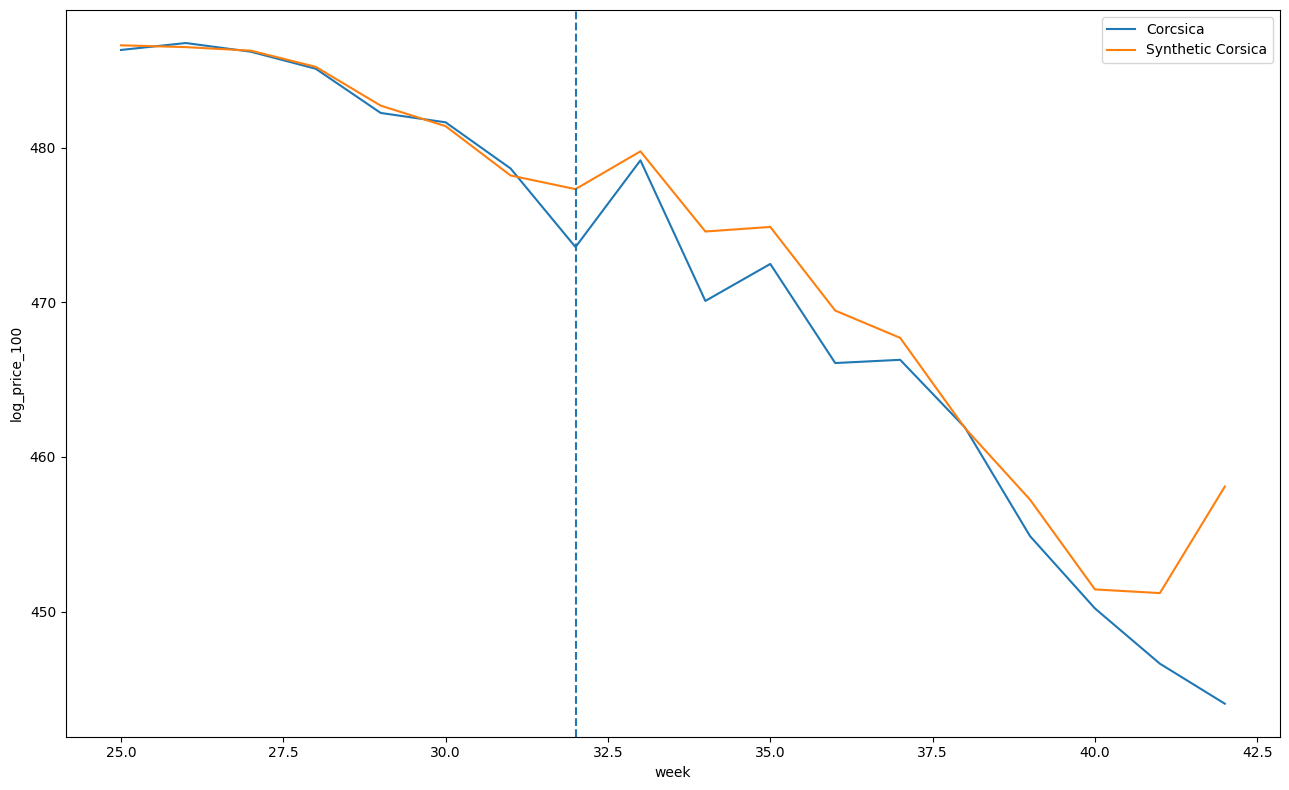

In [102]:
plt.figure(figsize=(13, 8))
plt.plot(series["week_src"], series["Corsica"], label="Corcsica")
plt.plot(series["week_src"], series["Synthetic Corsica"], label="Synthetic Corsica")
plt.axvline(32, linestyle="--")
plt.xlabel("week")
plt.ylabel("log_price_100")
plt.legend()
plt.tight_layout()
plt.show()

In [124]:
# Все по сути так же, как и в прошлом блоке
def pre_solver_v_pl(v_raw):
    v = softmax(v_raw)
    try:
        w = solver_w(X1_pl, X0_pl, v=v)
    except Exception:
        return 1e9
    y_syn = Y0_pre_pl @ w
    return float(np.sqrt(np.mean((Y1_pre_pl - y_syn) ** 2)))

donors_pl = donors
donors_arr_pl = np.array(donors_pl)
K = len(predictors)

pre_df_pl = df_synth[df_synth["week_src"] < 29].copy()
pre_weeks_pl = sorted(pre_df_pl["week_src"].unique())

X_pl = pre_df_pl.groupby("classification")[predictors].mean()

mu = X_pl.loc[donors_pl].mean(axis=0)
sd = X_pl.loc[donors_pl].std(axis=0).replace(0, 1.0)

X_pl_s = (X_pl - mu) / sd
X1_pl = X_pl_s.loc[1].to_numpy(dtype=float)
X0_pl = X_pl_s.loc[donors_pl].to_numpy(dtype=float).T

Y_pre_pl = pre_df_pl.pivot_table(index="week_src", columns="classification", values="lprice100", aggfunc="mean").loc[pre_weeks_pl]
Y1_pre_pl = Y_pre_pl[1].to_numpy(dtype=float)
Y0_pre_pl = Y_pre_pl[donors_pl].to_numpy(dtype=float)

# Оптимизируем v и получаем финальные веса доноров w для плацебо-настройки
opt_pl = minimize(pre_solver_v_pl, x0=np.zeros(K), method="Powell", options={"maxiter": 40, "disp": False})
v_pl = softmax(opt_pl.x)
w_pl = solver_w(X1_pl, X0_pl, v=v_pl)

# Строим синтетическую траекторию по всем неделям с весами w_pl
syn = []
for t in all_weeks:
    y = Y_all.loc[t, donors_arr_pl].to_numpy(dtype=float)
    ok = np.isfinite(y)

    if ok.sum() == 0:
        syn.append(np.nan)
    else:
        w_adj = w_pl[ok] / w_pl[ok].sum()
        syn.append(float(y[ok] @ w_adj))

# Итог: Корсика vs синтетика и разрыв при ложной дате вмешательства
series_pl = pd.DataFrame({"week_src": all_weeks, 
                       "Corsica": Y_all[1].to_numpy(dtype=float), 
                       "Synthetic Corsica": syn
                      })
series_pl["gap"] = series_pl["Corsica"] - series_pl["Synthetic Corsica"]

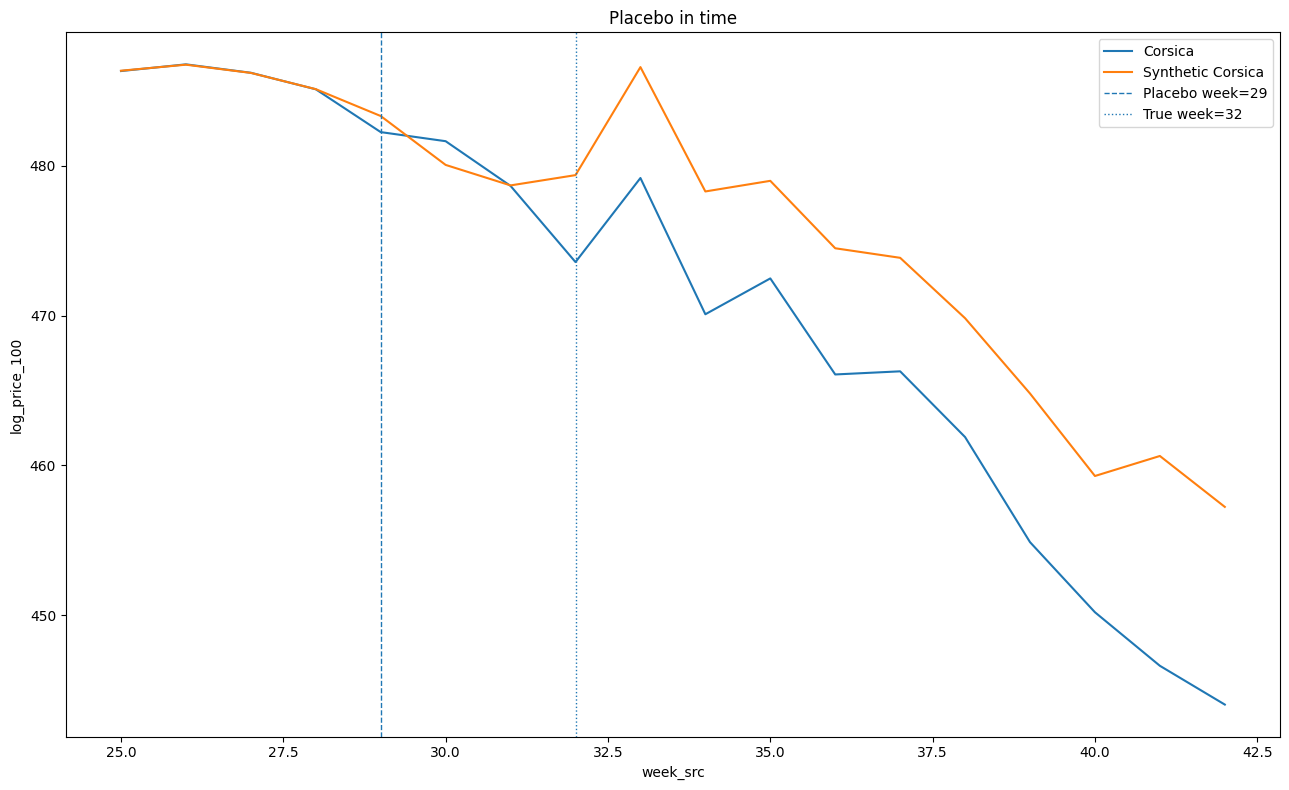

In [150]:
plt.figure(figsize=(13, 8))
plt.plot(series_pl["week_src"], series_pl["Corsica"], label="Corsica")
plt.plot(series_pl["week_src"], series_pl["Synthetic Corsica"], label="Synthetic Corsica")
plt.axvline(29, linestyle="--", linewidth=1, label="Placebo week=29")
plt.axvline(32, linestyle=":", linewidth=1, label="True week=32")
plt.legend()
plt.xlabel("week_src")
plt.ylabel("log_price_100")
plt.title("Placebo in time")
plt.tight_layout()
plt.show()


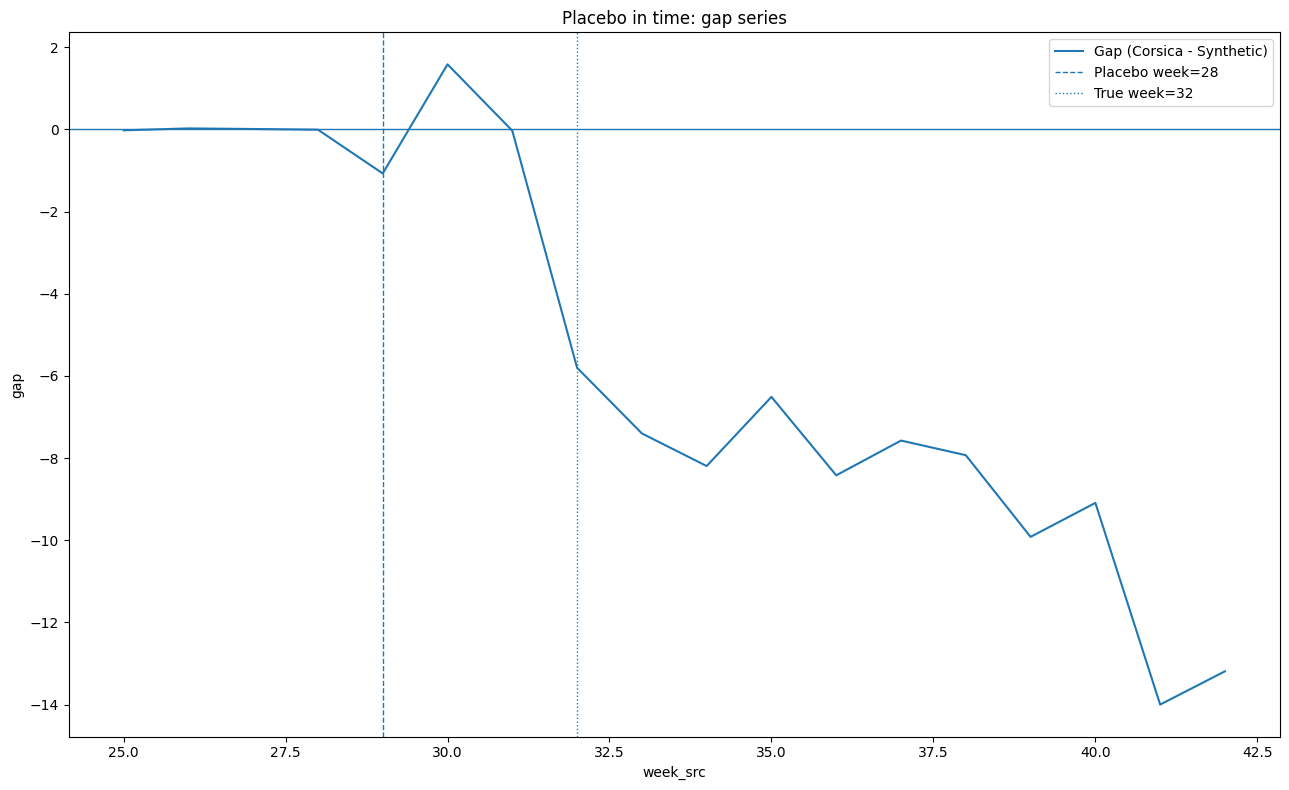

In [151]:
plt.figure(figsize=(13, 8))
plt.plot(series_pl["week_src"], series_pl["gap"], label="Gap (Corsica - Synthetic)")
plt.axhline(0, linewidth=1)
plt.axvline(29, linestyle="--", linewidth=1, label="Placebo week=28")
plt.axvline(32, linestyle=":", linewidth=1, label="True week=32")
plt.legend()
plt.xlabel("week_src")
plt.ylabel("gap")
plt.title("Placebo in time: gap series")
plt.tight_layout()
plt.show()

In [161]:
# Еще раз вычислим все для Корсики
def pre_solver_v_true(v_raw):
    v = softmax(v_raw)
    try:
        w = solver_w(X1_true, X0_true, v=v)
    except Exception:
        return 1e9
    y_syn = Y0_pre_true @ w
    return float(np.sqrt(np.mean((Y1_pre_true - y_syn) ** 2)))

K = len(predictors)

all_weeks = sorted(df_synth["week_src"].unique())
units = sorted(df_synth["classification"].unique())

Y_all = df_synth.pivot_table(index="week_src", columns="classification", values="lprice100", aggfunc="mean").loc[all_weeks]

donors_true = [u for u in units if u != 1]
donors_arr_true = np.array(donors_true)

pre_df_true = df_synth[df_synth["week_src"] < 32].copy()
pre_weeks_true = sorted(pre_df_true["week_src"].unique())

X_true = pre_df_true.groupby("classification")[predictors].mean()

mu_true = X_true.loc[donors_true].mean(axis=0)
sd_true = X_true.loc[donors_true].std(axis=0).replace(0, 1.0)

X_true_s = (X_true - mu_true) / sd_true
X1_true = X_true_s.loc[1].to_numpy(dtype=float)
X0_true = X_true_s.loc[donors_true].to_numpy(dtype=float).T

Y_pre_true = pre_df_true.pivot_table(index="week_src", columns="classification", values="lprice100", aggfunc="mean").loc[pre_weeks_true]
Y1_pre_true = Y_pre_true[1].to_numpy(dtype=float)
Y0_pre_true = Y_pre_true[donors_true].to_numpy(dtype=float)

opt_true = minimize(pre_solver_v_true, x0=np.zeros(K), method="Powell", options={"maxiter": 40, "disp": False})
v_true = softmax(opt_true.x)
w_true = solver_w(X1_true, X0_true, v=v_true)

syn_true = []
for t in all_weeks:
    y = Y_all.loc[t, donors_arr_true].to_numpy(dtype=float)
    ok = np.isfinite(y)
    if ok.sum() == 0:
        syn_true.append(np.nan)
    else:
        w_adj = w_true[ok] / w_true[ok].sum()
        syn_true.append(float(y[ok] @ w_adj))

series_true = pd.DataFrame({
    "week_src": all_weeks,
    "Treated": Y_all[1].to_numpy(dtype=float),
    "Synthetic": syn_true
})
series_true["gap"] = series_true["Treated"] - series_true["Synthetic"]

# RMSPE до и после вмешательства + отношение post/pre 
g = series_true["gap"].to_numpy(dtype=float)
t = series_true["week_src"].to_numpy(dtype=int)
pre_mask = np.isfinite(g) & (t < 32)
post_mask = np.isfinite(g) & (t >= 32)

pre_rmspe_true = np.sqrt(np.mean(g[pre_mask] ** 2))
post_rmspe_true = np.sqrt(np.mean(g[post_mask] ** 2))
ratio_true = post_rmspe_true / pre_rmspe_true

print("Corsica (TRUE): pre RMSPE =", pre_rmspe_true, "post RMSPE =", post_rmspe_true, "ratio =", ratio_true)

placebo_series = []
placebo_stats = []

# Повторяем SCM для каждой контрольной единицы
for treated_pl in units:
    if treated_pl == 1:
        continue

    donors_pl = [u for u in units if u != treated_pl]
    donors_arr_pl = np.array(donors_pl)

    X_pl = pre_df_true.groupby("classification")[predictors].mean()
    
    mu_pl = X_pl.loc[donors_pl].mean(axis=0)
    sd_pl = X_pl.loc[donors_pl].std(axis=0).replace(0, 1.0)
    
    X_pl_s = (X_pl - mu_pl) / sd_pl
    X1_pl = X_pl_s.loc[treated_pl].to_numpy(dtype=float)
    X0_pl = X_pl_s.loc[donors_pl].to_numpy(dtype=float).T

    try:
        w_pl = solver_w(X1_pl, X0_pl, v=v_true)
    except Exception:
        continue

    syn_pl = []
    for t in all_weeks:
        y = Y_all.loc[t, donors_arr_pl].to_numpy(dtype=float)
        ok = np.isfinite(y)
        if ok.sum() == 0:
            syn_pl.append(np.nan)
        else:
            w_adj = w_pl[ok] / w_pl[ok].sum()
            syn_pl.append(float(y[ok] @ w_adj))

    s_pl = pd.DataFrame({
        "week_src": all_weeks,
        "gap": Y_all[treated_pl].to_numpy(dtype=float) - np.array(syn_pl, dtype=float),
        "treated_unit": treated_pl
    })

    gpl = s_pl["gap"].to_numpy(dtype=float)
    wk = s_pl["week_src"].to_numpy(dtype=int)

    pre_m = np.isfinite(gpl) & (wk < 32)
    post_m = np.isfinite(gpl) & (wk >= 32)

    pre_r = np.sqrt(np.mean(gpl[pre_m] ** 2))
    post_r = np.sqrt(np.mean(gpl[post_m] ** 2))
    ratio = post_r / pre_r if pre_r > 0 else np.nan

    placebo_series.append(s_pl)
    placebo_stats.append({"unit": treated_pl, "pre_rmspe": pre_r, "post_rmspe": post_r, "ratio": ratio})

# Ранжируем плацебо по ratio
ratios_df = pd.DataFrame(placebo_stats).dropna(subset=["ratio"]).sort_values("ratio", ascending=False).reset_index(drop=True)

# Место Корсики в этом ранжировании
rank_true = 1 + (ratios_df["ratio"] > ratio_true).sum()
print("\nCorsica rank among placebos (higher ratio = stronger):", rank_true, "out of", len(ratios_df))

print("\nTop 10 placebo ratios:")
print(ratios_df.head(10))

Corsica (TRUE): pre RMSPE = 0.30981330115019545 post RMSPE = 5.034242394291036 ratio = 16.24927779279066

Corsica rank among placebos (higher ratio = stronger): 2 out of 18

Top 10 placebo ratios:
   unit  pre_rmspe  post_rmspe      ratio
0     8   0.976318   23.728198  24.303756
1    20   2.452545   17.297655   7.052940
2    22   6.686340   33.825246   5.058858
3     5   1.003773    4.919102   4.900614
4    14   2.449672   10.362743   4.230258
5     9   4.033234   16.915474   4.194023
6    16   1.684487    6.670071   3.959706
7     6   2.929622   10.860500   3.707134
8    21   2.768260   10.002387   3.613239
9    11   3.186856   11.290085   3.542703


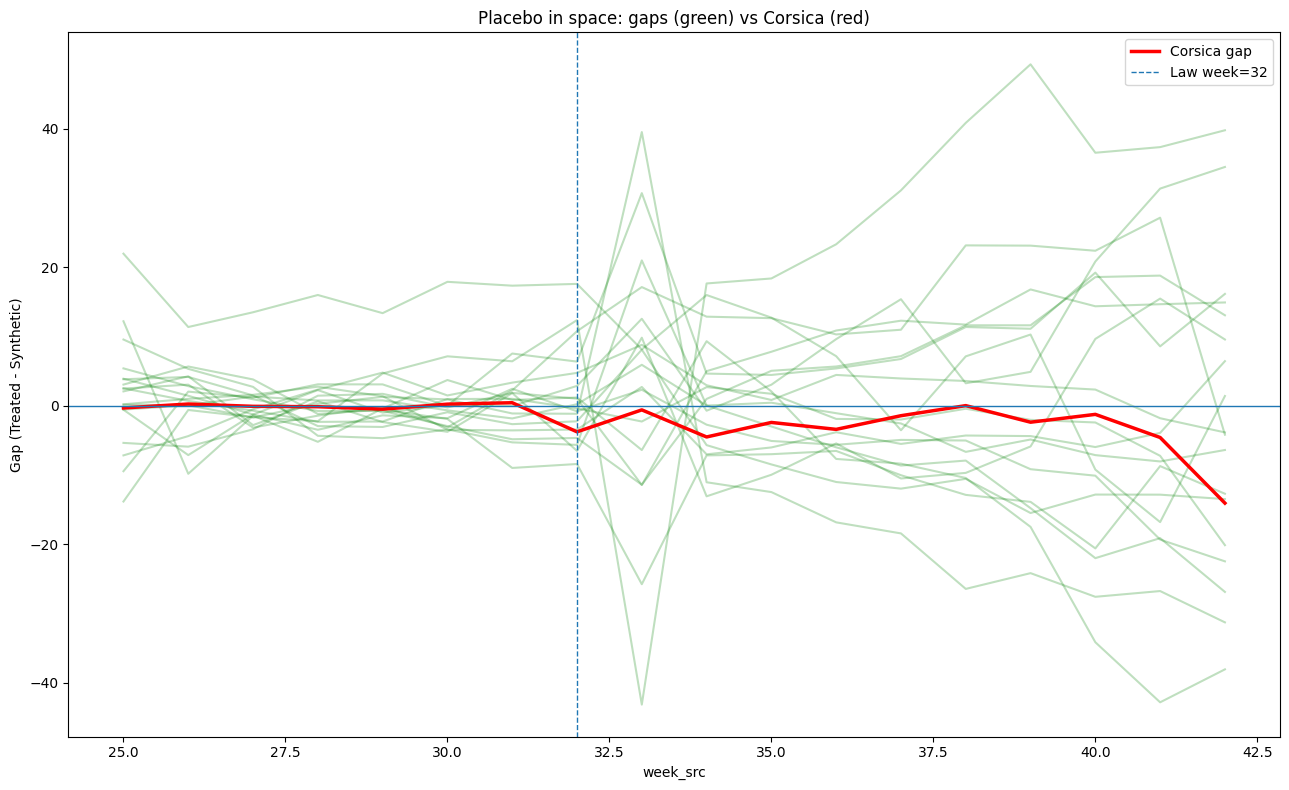

In [156]:
plt.figure(figsize=(13, 8))

for s in placebo_series:
    plt.plot(s["week_src"], s["gap"], "g", alpha=0.25)

plt.plot(series_true["week_src"], series_true["gap"], "r", linewidth=2.5, label="Corsica gap")
plt.axvline(TREAT_WEEK, linestyle="--", linewidth=1, label="Law week=32")
plt.axhline(0, linewidth=1)

plt.title("Placebo in space: gaps (green) vs Corsica (red)")
plt.xlabel("week_src")
plt.ylabel("Gap (Treated - Synthetic)")
plt.legend()
plt.tight_layout()
plt.show()


In [171]:
# Делаем все то же самое, что и раньше, только еще каждый раз убираем одного важного донора
def pre_solver_v_loo(v_raw):
    v = softmax(v_raw)
    try:
        w = solver_w(X1_loo, X0_loo, v=v)
    except Exception:
        return 1e9
    y_syn = Y0_pre_loo @ w
    return float(np.sqrt(np.mean((Y1_pre_loo - y_syn) ** 2)))

weights_df = pd.DataFrame({"unit": donors_true, "w": w_true}).sort_values("w", ascending=False).reset_index(drop=True)
important_units = weights_df.loc[weights_df["w"] > 0.01, "unit"].tolist()

loo_series_list = []
loo_stats = []

for drop_unit in important_units:
    donors_loo = [u for u in donors_true if u != drop_unit]
    donors_arr_loo = np.array(donors_loo)

    X_loo = pre_df_true.groupby("classification")[predictors].mean()
    mu_loo = X_loo.loc[donors_loo].mean(axis=0)
    sd_loo = X_pl.loc[donors_loo].std(axis=0).replace(0, 1.0)
    X_loo_s = (X_loo - mu_loo) / sd_loo

    X1_loo = X_loo_s.loc[1].to_numpy(dtype=float)
    X0_loo = X_loo_s.loc[donors_loo].to_numpy(dtype=float).T

    Y_pre_loo = pre_df_true.pivot_table(index="week_src", columns="classification", values="lprice100", aggfunc="mean").loc[pre_weeks_true]

    Y1_pre_loo = Y_pre_loo[1].to_numpy(dtype=float)
    Y0_pre_loo = Y_pre_loo[donors_loo].to_numpy(dtype=float)
    
    opt_loo = minimize(pre_solver_v_loo, x0=np.zeros(K), method="Powell", options={"maxiter": 40, "disp": False})
    v_loo = softmax(opt_loo.x)
    w_loo = solver_w(X1_loo, X0_loo, v=v_loo)

    syn_loo = []
    for wk in all_weeks:
        y = Y_all.loc[wk, donors_arr_loo].to_numpy(dtype=float)
        ok = np.isfinite(y)
        if ok.sum() == 0:
            syn_loo.append(np.nan)
        else:
            w_adj = w_loo[ok] / w_loo[ok].sum()
            syn_loo.append(float(y[ok] @ w_adj))

    s = pd.DataFrame({
        "week_src": all_weeks,
        "gap": series_true["Treated"].to_numpy(dtype=float) - np.array(syn_loo, dtype=float),
    })
    s["drop_unit"] = drop_unit
    loo_series_list.append(s)

    post_gap_mean = s.loc[s["week_src"] >= 32, "gap"].mean()
    loo_stats.append({
        "dropped": drop_unit,
        "pre_rmspe": float(opt_loo.fun),
        "post_gap_mean": float(post_gap_mean),
    })

loo_stats_df = pd.DataFrame(loo_stats).sort_values("pre_rmspe").reset_index(drop=True)
print("Leave-one-out summary:")
print(loo_stats_df)

Leave-one-out summary:
   dropped  pre_rmspe  post_gap_mean
0       18   0.387685      -3.906471
1        6   0.695600      -6.342452
2        9   0.800149      -2.737445
3       12   1.023142      -6.450124


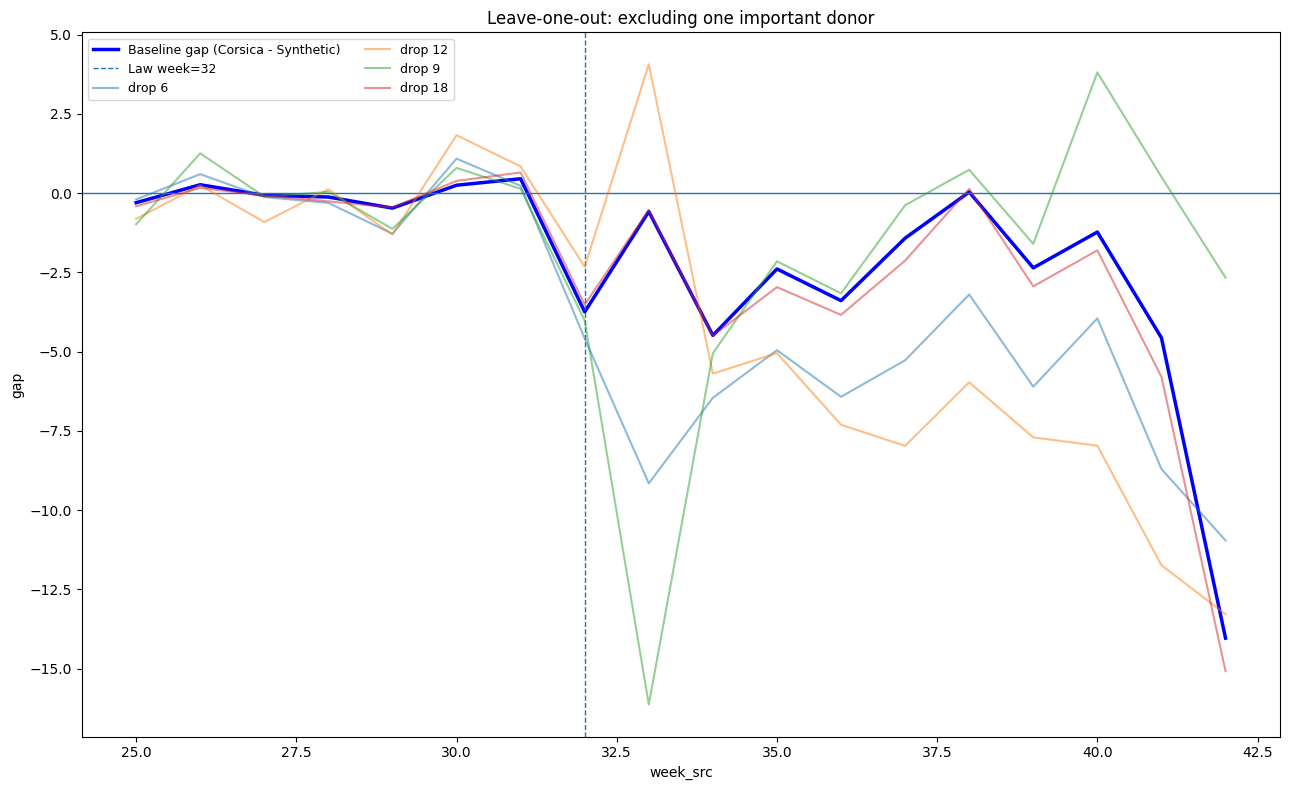

In [170]:
plt.figure(figsize=(13, 8))
plt.plot(series_true["week_src"], series_true["gap"], "b",linewidth=2.5, label="Baseline gap (Corsica - Synthetic)")
plt.axvline(32, linestyle="--", linewidth=1, label="Law week=32")
plt.axhline(0, linewidth=1)

for s in loo_series_list:
    lab = f"drop {int(s['drop_unit'].iloc[0])}"
    plt.plot(s["week_src"], s["gap"], alpha=0.5, label=lab)

plt.title("Leave-one-out: excluding one important donor")
plt.xlabel("week_src")
plt.ylabel("gap")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()